In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pmdarima import auto_arima

In [3]:
dataset = pd.read_csv('m_indexed_dataset.csv')

In [8]:
dataset.datetime = pd.to_datetime(dataset.datetime)

In [13]:
dataset['energy'].notna().count()

94992

In [29]:
x = dataset.drop(['energy'], axis=1)

In [30]:
x

,datetime,row_id
0,2008-03-01 00:00:00,1
1,2008-03-01 01:00:00,2
2,2008-03-01 02:00:00,3
3,2008-03-01 03:00:00,4
4,2008-03-01 04:00:00,5
...,...,...
94987,2018-12-31 19:00:00,94988
94988,2018-12-31 20:00:00,94989
94989,2018-12-31 21:00:00,94990
94990,2018-12-31 22:00:00,94991


In [17]:
model = auto_arima(dataset,seasonal=True,m=12)

TypeError: The DType <class 'numpy.dtype[datetime64]'> could not be promoted by <class 'numpy.dtype[float64]'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtype[datetime64]'>, <class 'numpy.dtype[int64]'>, <class 'numpy.dtype[float64]'>)

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX 

In [22]:
model = SARIMAX(dataset['energy'])

In [59]:
result = model.fit()
result.predict(x['datetime'])

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

In [35]:
import matplotlib.pyplot as mat

In [38]:
result = model.fit()

In [39]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 energy   No. Observations:                94992
Model:               SARIMAX(1, 0, 0)   Log Likelihood             -518378.659
Date:                Wed, 19 Jun 2024   AIC                        1036761.318
Time:                        16:02:53   BIC                        1036780.241
Sample:                             0   HQIC                       1036767.074
                              - 94992                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9993      0.000   8881.156      0.000       0.999       1.000
sigma2      3962.5988     14.358    275.977      0.000    3934.457    3990.741
===================================================================================
Ljung-Box (L1) (Q):               54765.69   Jarque-Bera (JB):              7978.50
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.72   Skew:                             0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94992 entries, 0 to 94991
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  94992 non-null  datetime64[ns]
 1   row_id    94992 non-null  int64         
 2   energy    93092 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.2 MB


In [45]:
test_dataset = pd.read_csv('test.csv')

In [51]:
test_dataset.datetime = pd.to_datetime(test_dataset.datetime)

In [52]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   row_id    26304 non-null  int64         
 1   datetime  26304 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 411.1 KB


<Axes: >

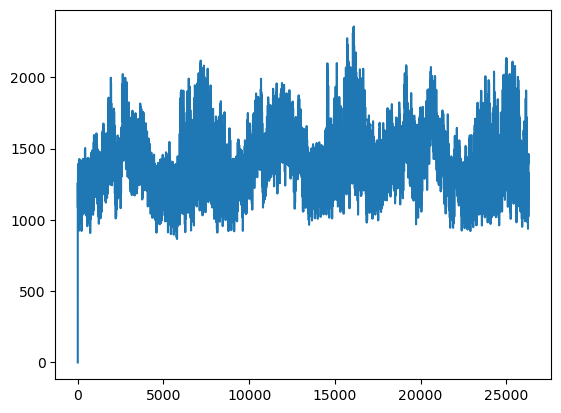

In [58]:
end = len(test_dataset)-1
P = result.predict(0,end).rename('Predictions')
P.plot()
#dataset.energy.plot()